In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)
pd.set_option('display.max_rows', None)
ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)

RESAMPLE_RULE = "1S"

TEST_FILE_NAME = "2021-05-25-10-46-56-moving-v2-1-west-walking-speed"

In [2]:
def generate_stats_pairwise(veh_df, veh, df_with_overall_time, master_slave_mapping, main_master):
    stats_list = []
    # pairwise stats
    if df_with_overall_time == None:
        df_with_overall_time = veh_df
    time_stamp_lim = get_time_stamp_lim(veh_df, df_with_overall_time_duration=df_with_overall_time)
    for master_id in master_slave_mapping.keys():
        for slave_id in master_slave_mapping[master_id]:
            df_pairwise_sliced = veh_df[(veh_df["Initiating Master"] == master_id) & (veh_df["Reporting Slave"] == slave_id)]
            pairwise_stats_map = {}
            pairwise_stats_map['Test Name'] = raw_name
            pairwise_stats_map['Operation Duration'] = (time_stamp_lim[1] - time_stamp_lim[0]).total_seconds()
            pairwise_stats_map['Measuring Vehicle'] = veh
            pairwise_stats_map['Measuring Master'] = master_id
            pairwise_stats_map['Is Main Master'] = True if master_id == main_master else False
            pairwise_stats_map['Measuring Slave'] = slave_id
            pairwise_stats_map['Is Main Slave'] = True if master_slave_mapping[master_id][0] == slave_id else False
            pairwise_stats_map['Is Aggregated'] = False
            if df_pairwise_sliced.empty or df_pairwise_sliced["Correction Distance (mm)"].isnull().all():
                pairwise_stats_map['Downtime Periods'] = [time_stamp_lim]
                pairwise_stats_map['Downtime Duration'] = (time_stamp_lim[1] - time_stamp_lim[0]).total_seconds()
                pairwise_stats_map['Reporting Counts'] = len(df_pairwise_sliced.index)
                stats_list.append(pairwise_stats_map)
                continue
            pairwise_stats_map['Ground Truth (mm)'] = df_pairwise_sliced["Surveyed Distance (mm)"].get(0, float('nan'))
            pairwise_stats_map['Average Measurement (mm)'] = df_pairwise_sliced["Correction Distance (mm)"].mean()
            pairwise_stats_map['STD (mm)'] = df_pairwise_sliced["Correction Distance (mm)"].std()
            pairwise_stats_map['Operation Duration'] = (time_stamp_lim[1] - time_stamp_lim[0]).total_seconds()
            pairwise_stats_map['Reporting Counts'] = len(df_pairwise_sliced.index)
            pairwise_stats_map['Downtime Periods'] = get_nan_slices_indices(df_pairwise_sliced, veh, time_stamp_lim)
            pairwise_stats_map['Downtime Duration'] = sum([(_stopt - _startt).total_seconds()
                                                              for [_startt, _stopt] in 
                                                              get_nan_slices_indices(df_pairwise_sliced.resample(rule=RESAMPLE_RULE).mean(), 
                                                                                     veh, 
                                                                                     time_stamp_lim)])
            
            stats_list.append(pairwise_stats_map)
    return pd.DataFrame(stats_list)

def generate_stats_aggregated(veh_df, veh, df_with_overall_time):
    stats_list = []
    # aggregated stats
    time_stamp_lim = get_time_stamp_lim(veh_df, df_with_overall_time_duration=df_with_overall_time)
    agg_stats_map = {}
    agg_stats_map['Test Name'] = raw_name
    agg_stats_map['Measuring Vehicle'] = veh
    agg_stats_map['Is Aggregated'] = True
    agg_stats_map['Ground Truth (mm)'] = veh_df["Surveyed Distance (mm)"].get(0, float('nan'))
    agg_stats_map['Average Measurement (mm)'] = veh_df["Correction Distance (mm)"].mean()
    agg_stats_map['STD (mm)'] = veh_df["Correction Distance (mm)"].std()
    agg_stats_map['Operation Duration'] = (time_stamp_lim[1] - time_stamp_lim[0]).total_seconds()
    agg_stats_map['Downtime Periods'] = get_nan_slices_indices(veh_df, veh, time_stamp_lim)
    agg_stats_map['Downtime Duration'] = sum([(_stopt - _startt).total_seconds()
                                              for [_startt, _stopt] in 
                                              get_nan_slices_indices(veh_df.resample(rule=RESAMPLE_RULE).mean(), 
                                                                     veh, 
                                                                     time_stamp_lim)])
    agg_stats_map['Reporting Counts'] = len(veh_df.index)
    return pd.DataFrame([agg_stats_map])

In [3]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_rows', None)
RESAMPLE_RULE = "1S"

static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
static_veh, moving_veh = 1, 2

static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

for test_file in get_test_files_and_survey("Static Test", "V2")[0]:
    if "data-A-user-processed_log" in test_file and os.path.basename(test_file).startswith("2021"):
        continue
    _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
    _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
    _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
    
    base_folder = os.path.dirname(_integ_csv_dir)
    raw_name = os.path.basename(os.path.dirname(_integ_csv_dir))
    print("processing: " + raw_name)
    df = pd.read_csv(_integ_csv_dir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
    
    df["Aggregated Update Rate (Hz)"] = np.nan
    df['UWB Measured Instant Speed - Strict Pair (mph)'] = np.nan
    df['Aggregated Measured Speed (mph)'] = np.nan
    # Filter out distance measurement outliers 
    df, df_outlier = uwb_dist_outlier_identify(df, segments = 5)
    # Remove duplicated index
    _newindex = df.reset_index().groupby("Datetime Normalized")["Datetime Normalized"].apply(lambda x: x + np.arange(x.size).astype('timedelta64[ms]'))
    df.index = _newindex
    if df.empty:
        print(raw_name + " No Data")
        continue


    df_static_veh_all_pairs = df[df['Initiating Vehicle'] == static_veh]
    df_moving_veh_all_pairs = df[df['Initiating Vehicle'] == moving_veh]
    df_static_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    df_moving_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)

    df_static_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(        df_static_veh_all_pairs, 
                                                                                static_master_slave_mapping.keys(), 
                                                                                static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(        df_moving_veh_all_pairs, 
                                                                                moving_master_slave_mapping.keys(), 
                                                                                moving_focusing_slaves)
    df_static_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(        df_static_veh_hz_aggregated_all_pairs, 
                                                                                static_master_slave_mapping.keys(), 
                                                                                static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(        df_moving_veh_hz_aggregated_all_pairs, 
                                                                                moving_master_slave_mapping.keys(), 
                                                                                moving_focusing_slaves)
    
    df_static_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    df_moving_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    
    # Stats generate
    df_stats_pairwise_static = generate_stats_pairwise(df_static_veh_hz_aggregated_all_pairs, 
                                                       static_veh, 
                                                       None, 
                                                       static_master_slave_mapping, 
                                                       static_main_master)
    df_stats_aggregated_static = generate_stats_aggregated(df_static_veh_hz_aggregated_all_pairs, 
                                                           static_veh, 
                                                           None)
    static_stats_list_pairwise.append(df_stats_pairwise_static)
    static_stats_list_aggregated.append(df_stats_aggregated_static)
    df_stats_pairwise_moving = generate_stats_pairwise(df_moving_veh_hz_aggregated_all_pairs, 
                                                       moving_veh, 
                                                       None, 
                                                       moving_master_slave_mapping, 
                                                       moving_main_master)
    df_stats_aggregated_moving = generate_stats_aggregated(df_moving_veh_hz_aggregated_all_pairs, 
                                                           moving_veh, 
                                                           None)
    moving_stats_list_pairwise.append(df_stats_pairwise_moving)
    moving_stats_list_aggregated.append(df_stats_aggregated_moving)
    
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)

df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)

processing: 2021-05-25-08-47-11-static-v2-2
processing: 2021-05-25-08-52-15-static-v2-3
processing: 2021-05-25-08-55-36-static-v2-4
processing: 2021-05-25-09-08-13-static-v2-5
processing: 2021-05-25-09-12-21-static-v2-6
processing: 2021-05-25-09-16-22-static-v2-7
processing: 2021-05-25-09-20-18-static-v2-8
processing: 2021-05-25-09-23-50-static-v2-9
processing: 2021-05-25-09-27-41-static-v2-10
processing: 2021-05-25-09-31-46-static-v2-11
processing: 2021-05-25-09-35-42-static-v2-12
processing: 2021-05-25-09-39-16-static-v2-13
processing: 2021-05-25-09-42-52-static-v2-14


In [12]:
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated["Main Pair Counts"] = np.array(df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & (df_all_static_stats_pairwise["Is Main Slave"]==True)]["Reporting Counts"])
df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated["Main Pair Counts"] = np.array(df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & (df_all_moving_stats_pairwise["Is Main Slave"]==True)]["Reporting Counts"])

In [14]:
df_all_static_stats_aggregated

,Test Name,Measuring Vehicle,Is Aggregated,Ground Truth (mm),Average Measurement (mm),STD (mm),Operation Duration,Downtime Periods,Downtime Duration,Reporting Counts,Main Pair Counts
0,2021-05-25-08-47-11-static-v2-2,1,True,6002.00000,5852.78647,29.66697,147.59713,"[[2021-05-25 08:47:15.575574016, 2021-05-25 08...",0.59713,2941,1472
1,2021-05-25-08-52-15-static-v2-3,1,True,7800.00000,7626.53365,29.43615,148.59441,"[[2021-05-25 08:52:19.746878976, 2021-05-25 08...",0.59441,2719,1486
2,2021-05-25-08-55-36-static-v2-4,1,True,9541.00000,9358.88970,37.12740,147.19537,"[[2021-05-25 08:55:40.742127872, 2021-05-25 08...",1.19537,1505,1470
3,2021-05-25-09-08-13-static-v2-5,1,True,11277.60000,11472.60721,333.19183,147.00234,"[[2021-05-25 09:08:18.329530880, 2021-05-25 09...",0.66140,2276,1465
4,2021-05-25-09-12-21-static-v2-6,1,True,13093.70000,13104.54601,24.83443,147.19710,"[[2021-05-25 09:12:25.725543936, 2021-05-25 09...",1.19710,1467,1467
5,2021-05-25-09-16-22-static-v2-7,1,True,14973.30000,14989.80816,26.39198,147.50039,"[[2021-05-25 09:16:27.018822912, 2021-05-25 09...",0.53803,1470,1470
6,2021-05-25-09-20-18-static-v2-8,1,True,17246.60000,17272.96041,27.41860,147.10244,"[[2021-05-25 09:20:22.814941952, 2021-05-25 09...",1.10244,1465,1465
7,2021-05-25-09-23-50-static-v2-9,1,True,18986.50000,18994.65870,29.71204,147.30432,"[[2021-05-25 09:23:54.716387072, 2021-05-25 09...",0.30432,1465,1465
8,2021-05-25-09-27-41-static-v2-10,1,True,21736.00000,21759.69959,31.62116,147.69680,"[[2021-05-25 09:27:46.215780096, 2021-05-25 09...",1.69680,1478,1478
9,2021-05-25-09-31-46-static-v2-11,1,True,24650.70000,24726.74523,37.19950,147.19397,"[[2021-05-25 09:31:51.112820992, 2021-05-25 09...",1.19397,1468,1468


In [ ]:
df_all_moving_stats_pairwise

In [153]:
len(df_all_moving_stats_aggregated.index)

13

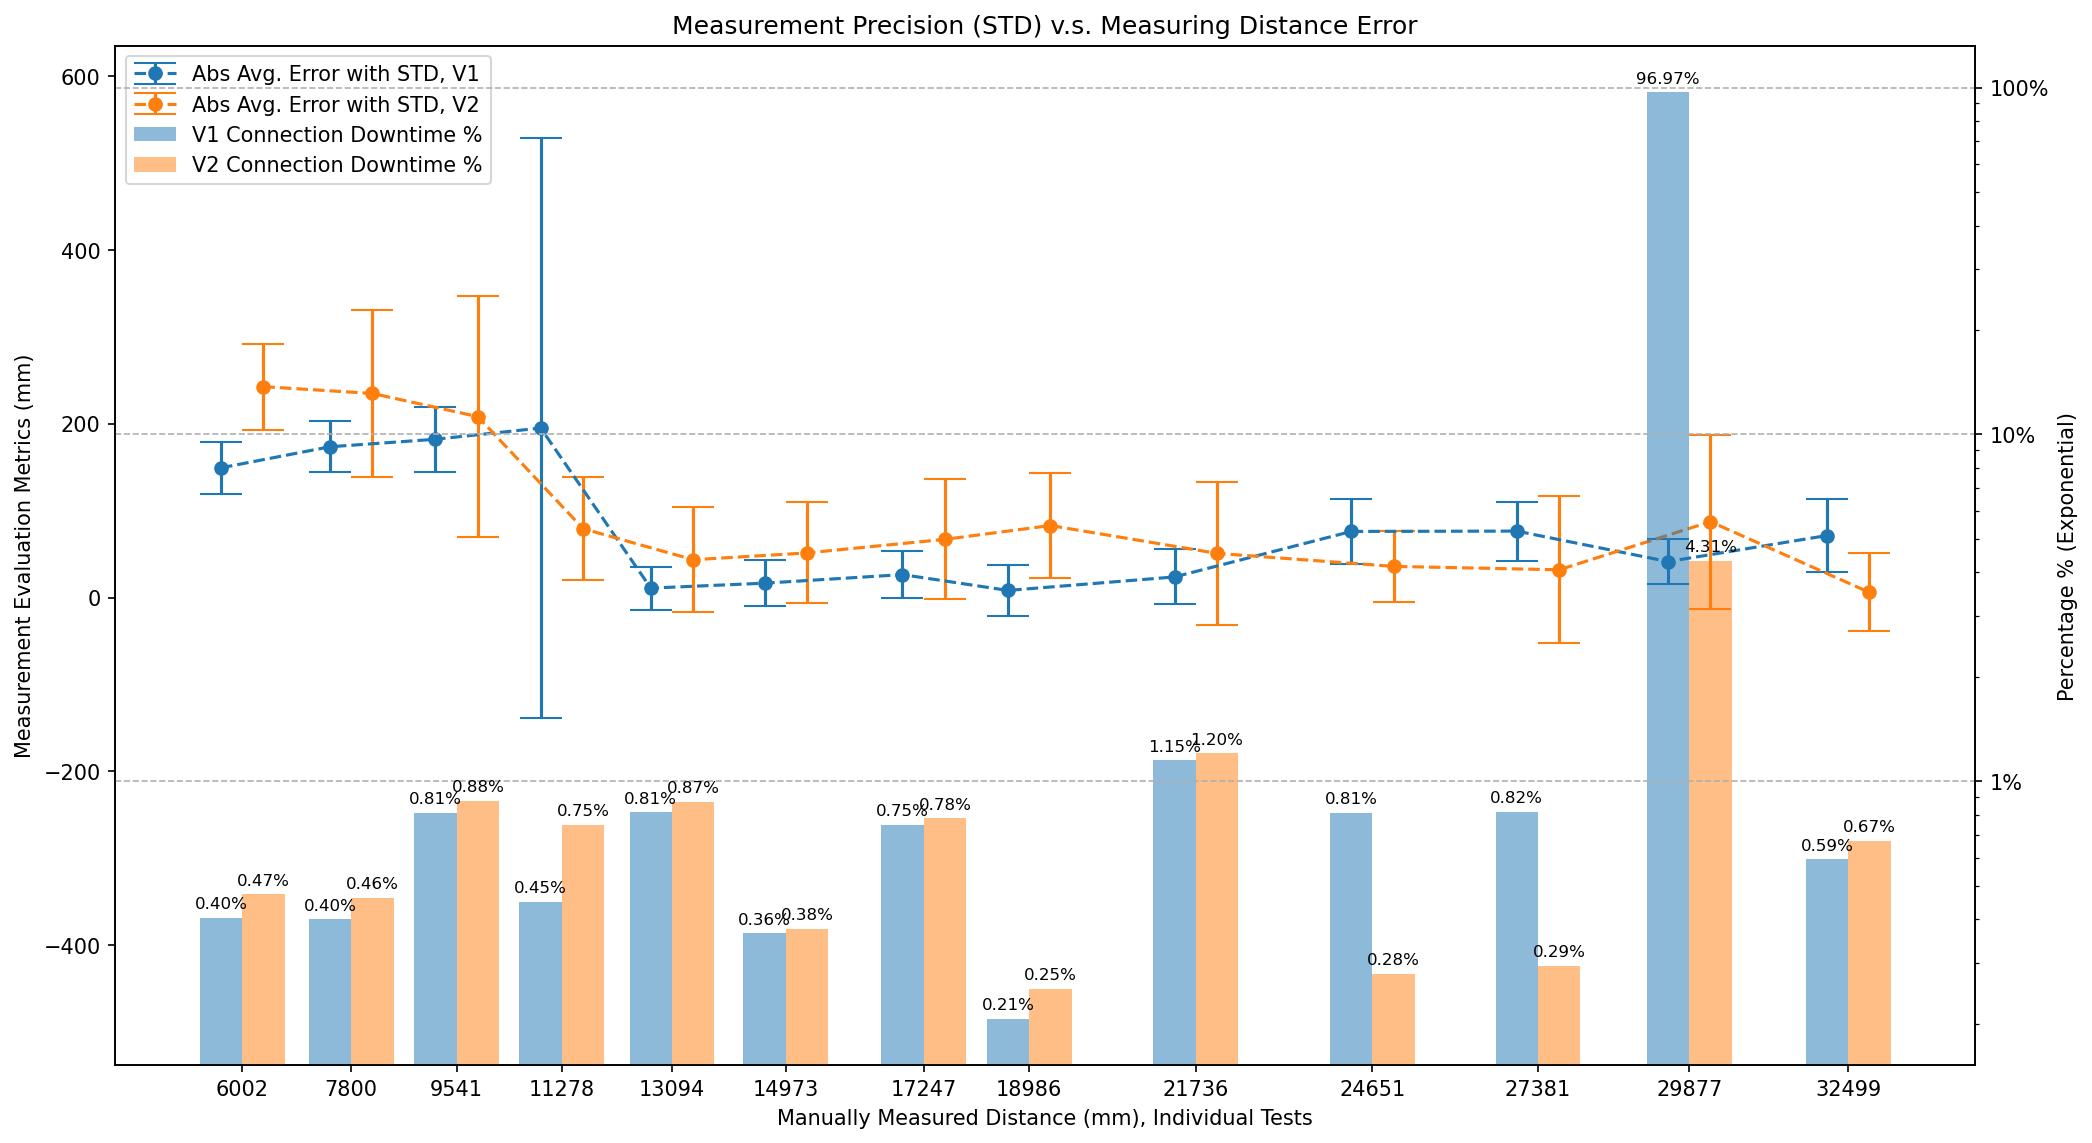

In [163]:
figure = plt.figure(figsize=(16, 9), dpi=150)
width = 700
labels = df_all_static_stats_aggregated["Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2, 
                       y=abs(df_all_static_stats_aggregated["Ground Truth (mm)"] - df_all_static_stats_aggregated["Average Measurement (mm)"]),
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=10,
                       linestyle='--',
                       marker='o',
                       label='Abs Avg. Error with STD, V{}'.format(static_veh))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated["Ground Truth (mm)"]+width/2, 
                       y=abs(df_all_moving_stats_aggregated["Ground Truth (mm)"] - df_all_moving_stats_aggregated["Average Measurement (mm)"]),
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=10,
                       linestyle='--',
                       marker='o',
                       label='Abs Avg. Error with STD, V{}'.format(moving_veh))
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error")
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated["Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2,
                 df_all_static_stats_aggregated["Downtime Duration"] / df_all_static_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(static_veh), alpha=0.5)
rects2 = ax2.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]+width/2, 
                 df_all_moving_stats_aggregated["Downtime Duration"] / df_all_moving_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(moving_veh), alpha=0.5)

ax2.set_ylabel("Percentage % (Exponential)")
ax2.set_yscale('log')
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x) for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x) for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_2, rects1, rects2], 
          [errbar_1.get_label(), errbar_2.get_label(), rects1.get_label(), rects2.get_label()], 
          loc='upper left')
plt.show()

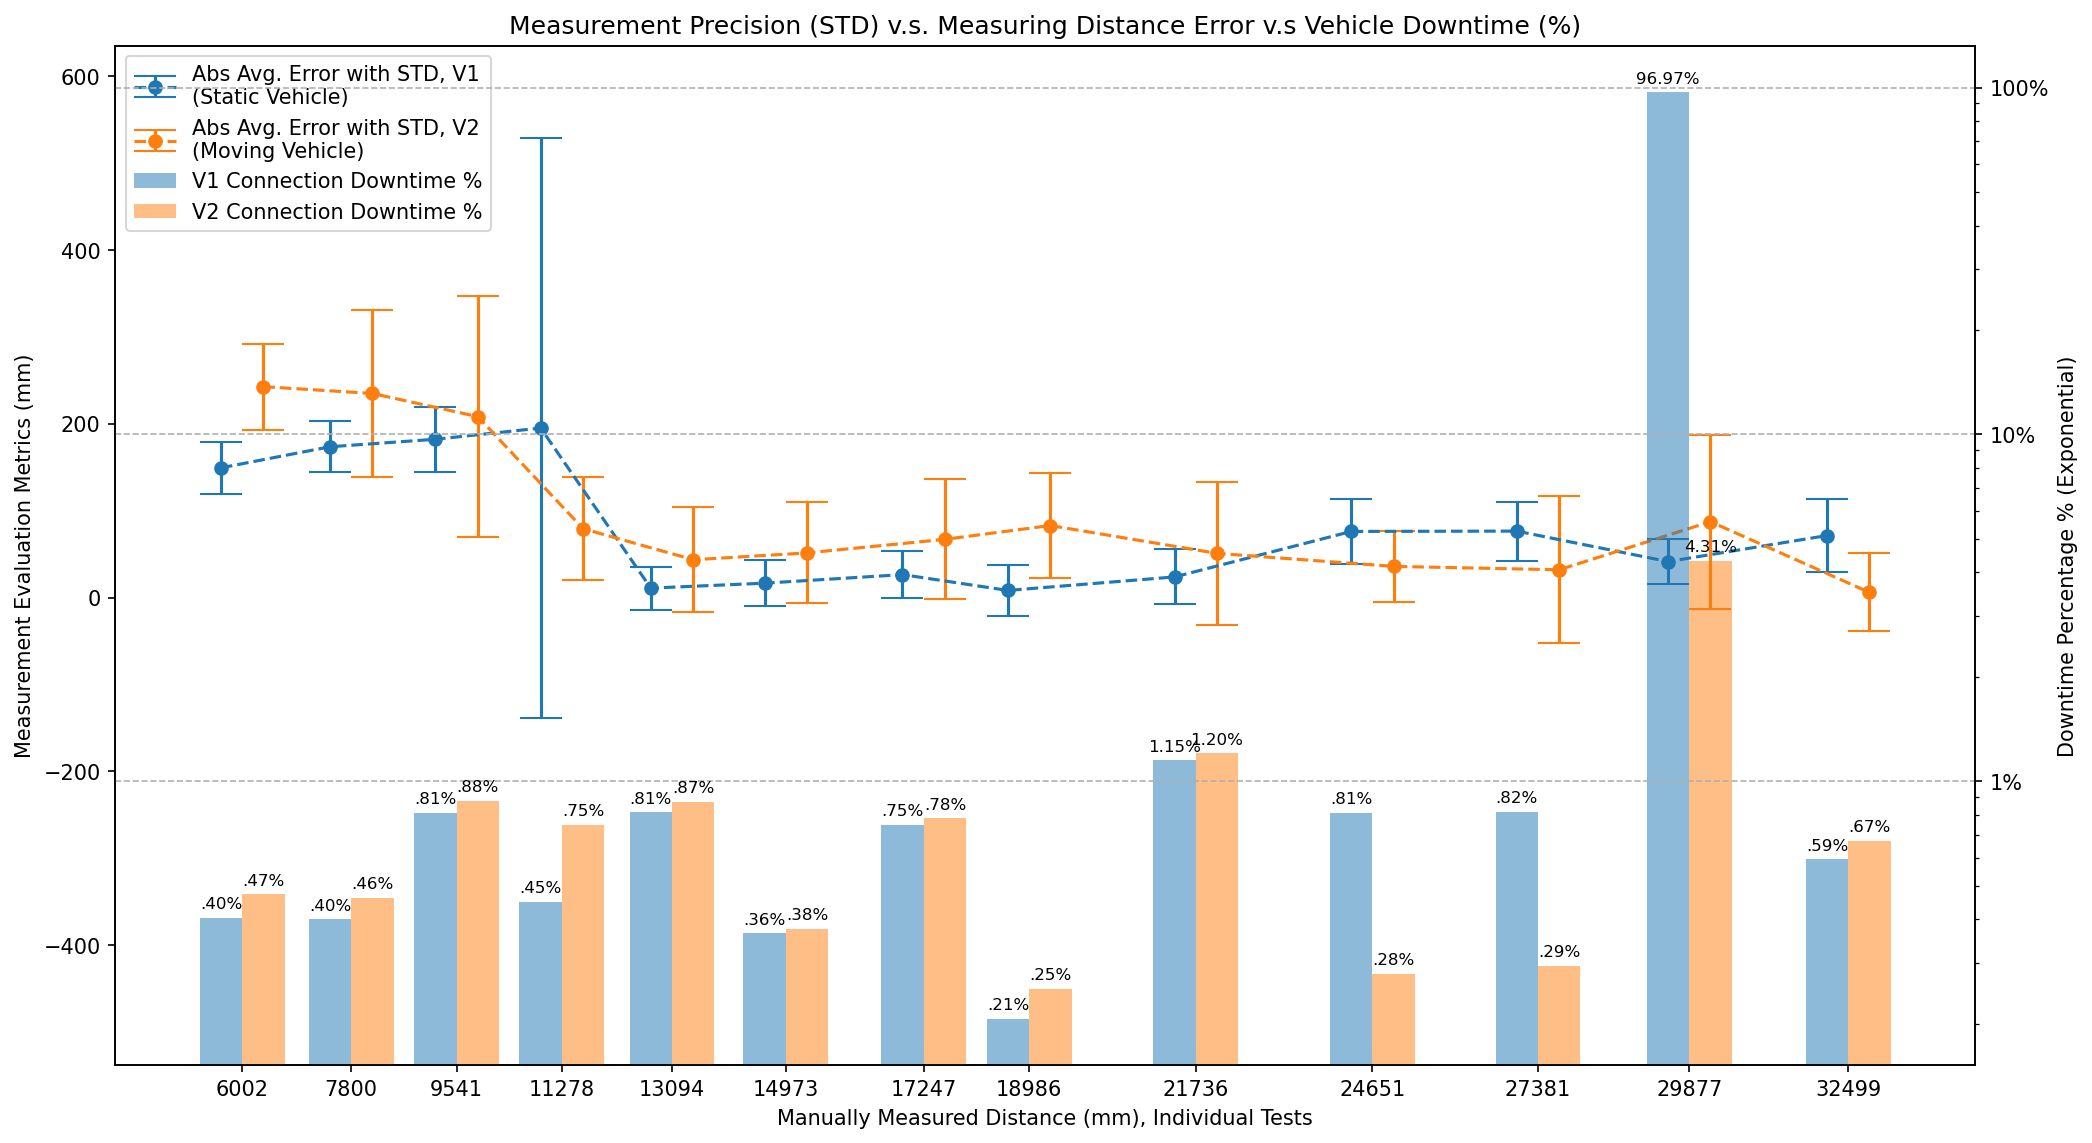

In [164]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width = 700
labels = df_all_static_stats_aggregated["Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s Vehicle Downtime (%)")
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2, 
                       y=abs(df_all_static_stats_aggregated["Ground Truth (mm)"] - df_all_static_stats_aggregated["Average Measurement (mm)"]),
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=10,
                       linestyle='--',
                       marker='o',
                       label='Abs Avg. Error with STD, V{}\n(Static Vehicle)'.format(static_veh))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated["Ground Truth (mm)"]+width/2, 
                       y=abs(df_all_moving_stats_aggregated["Ground Truth (mm)"] - df_all_moving_stats_aggregated["Average Measurement (mm)"]),
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=10,
                       linestyle='--',
                       marker='o',
                       label='Abs Avg. Error with STD, V{}\n(Moving Vehicle)'.format(moving_veh))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated["Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2,
                 df_all_static_stats_aggregated["Downtime Duration"] / df_all_static_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(static_veh), alpha=0.5)
rects2 = ax2.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]+width/2, 
                 df_all_moving_stats_aggregated["Downtime Duration"] / df_all_moving_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(moving_veh), alpha=0.5)

ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_yscale('log')
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_2, rects1, rects2], 
          [errbar_1.get_label(), errbar_2.get_label(), rects1.get_label(), rects2.get_label()], 
          loc='upper left')
plt.show()

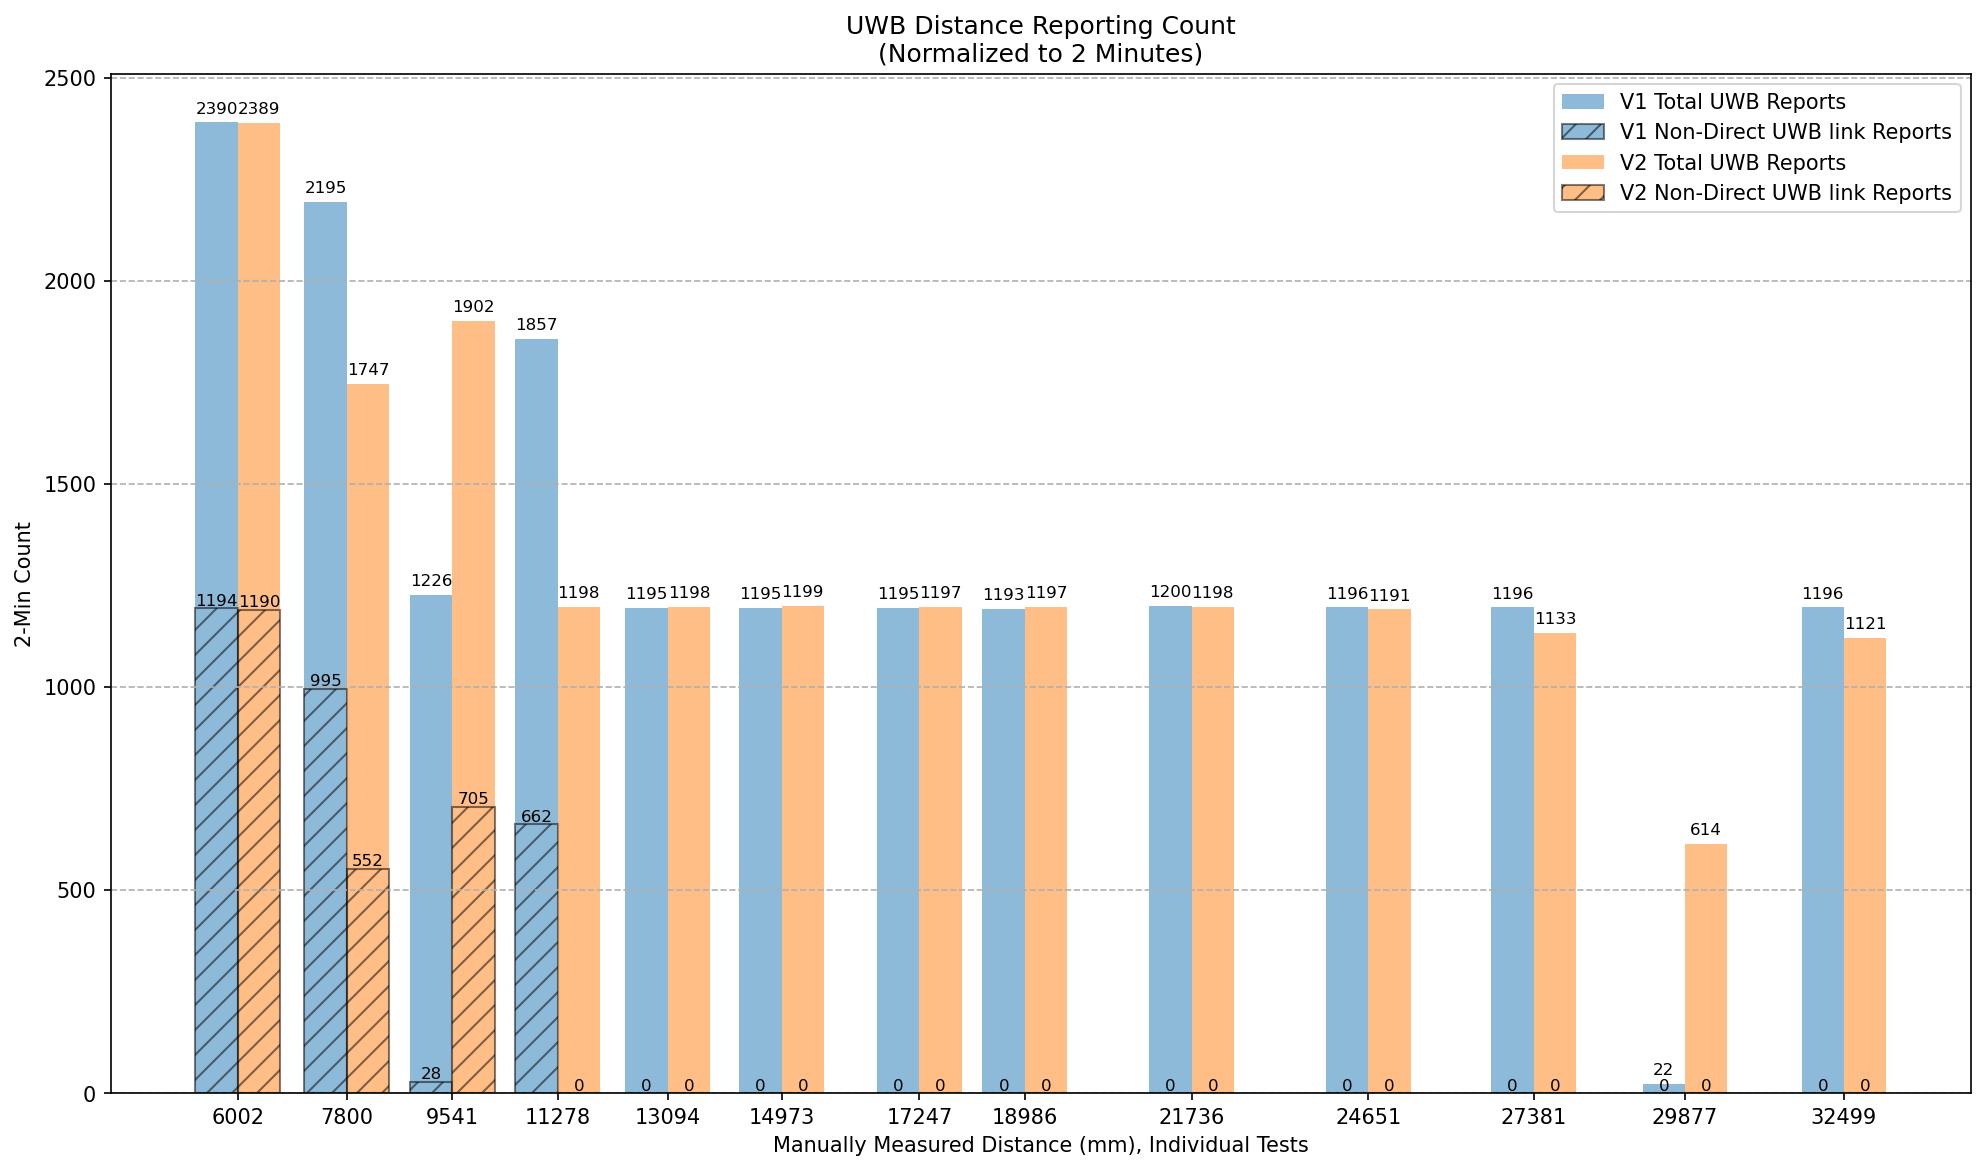

In [56]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width = 700
labels = df_all_static_stats_aggregated["Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("UWB Distance Reporting Count\n(Normalized to 2 Minutes)")

rects1 = ax.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2,
                (df_all_static_stats_aggregated["Main Pair Counts"]/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_static_stats_aggregated["Reporting Counts"] - df_all_static_stats_aggregated["Main Pair Counts"])/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(static_veh), alpha=0.5, color="C0")
rects0 = ax.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]-width/2,
                ((df_all_static_stats_aggregated["Reporting Counts"] - df_all_static_stats_aggregated["Main Pair Counts"])/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(static_veh), alpha=0.5, color="C0", hatch="//", edgecolor='k')


rects3 = ax.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]+width/2, 
                (df_all_moving_stats_aggregated["Main Pair Counts"]/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_moving_stats_aggregated["Reporting Counts"] - df_all_moving_stats_aggregated["Main Pair Counts"])/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(moving_veh), alpha=0.5, color="C1")
rects2 = ax.bar(df_all_static_stats_aggregated["Ground Truth (mm)"]+width/2, 
                ((df_all_moving_stats_aggregated["Reporting Counts"] - df_all_moving_stats_aggregated["Main Pair Counts"])/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(moving_veh), alpha=0.5, color="C1", hatch="//", edgecolor='k')


ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated["Ground Truth (mm)"])
ax.set_ylabel("2-Min Count")
ax.bar_label(rects1, padding=3, fontsize=8)
ax.bar_label(rects0, padding=0, fontsize=8)
ax.bar_label(rects3, padding=3, fontsize=8)
ax.bar_label(rects2, padding=0, fontsize=8)
ax.grid(axis='y', linestyle='--')

ax.legend()
plt.show()

In [35]:
df_all_static_stats_aggregated

,Test Name,Measuring Vehicle,Is Aggregated,Ground Truth (mm),Average Measurement (mm),STD (mm),Operation Duration,Downtime Periods,Downtime Duration,Reporting Counts,Main Pair Counts
0,2021-05-25-08-47-11-static-v2-2,1,True,6002.00000,5852.78647,29.66697,147.59713,"[[2021-05-25 08:47:15.575574016, 2021-05-25 08...",0.59713,2941,1472
1,2021-05-25-08-52-15-static-v2-3,1,True,7800.00000,7626.53365,29.43615,148.59441,"[[2021-05-25 08:52:19.746878976, 2021-05-25 08...",0.59441,2719,1486
2,2021-05-25-08-55-36-static-v2-4,1,True,9541.00000,9358.88970,37.12740,147.19537,"[[2021-05-25 08:55:40.742127872, 2021-05-25 08...",1.19537,1505,1470
3,2021-05-25-09-08-13-static-v2-5,1,True,11277.60000,11472.60721,333.19183,147.00234,"[[2021-05-25 09:08:18.329530880, 2021-05-25 09...",0.66140,2276,1465
4,2021-05-25-09-12-21-static-v2-6,1,True,13093.70000,13104.54601,24.83443,147.19710,"[[2021-05-25 09:12:25.725543936, 2021-05-25 09...",1.19710,1467,1467
5,2021-05-25-09-16-22-static-v2-7,1,True,14973.30000,14989.80816,26.39198,147.50039,"[[2021-05-25 09:16:27.018822912, 2021-05-25 09...",0.53803,1470,1470
6,2021-05-25-09-20-18-static-v2-8,1,True,17246.60000,17272.96041,27.41860,147.10244,"[[2021-05-25 09:20:22.814941952, 2021-05-25 09...",1.10244,1465,1465
7,2021-05-25-09-23-50-static-v2-9,1,True,18986.50000,18994.65870,29.71204,147.30432,"[[2021-05-25 09:23:54.716387072, 2021-05-25 09...",0.30432,1465,1465
8,2021-05-25-09-27-41-static-v2-10,1,True,21736.00000,21759.69959,31.62116,147.69680,"[[2021-05-25 09:27:46.215780096, 2021-05-25 09...",1.69680,1478,1478
9,2021-05-25-09-31-46-static-v2-11,1,True,24650.70000,24726.74523,37.19950,147.19397,"[[2021-05-25 09:31:51.112820992, 2021-05-25 09...",1.19397,1468,1468
